In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [81]:
df = pd.read_csv('/content/drive/MyDrive/ANALYTICS/E-commerce_Delivery_Shipping_Data_2026.csv')
df

,order_id,order_date,customer_id,customer_segment,customer_city,customer_country,warehouse_id,warehouse_city,product_category,product_weight_kg,...,package_size,payment_method,order_priority,weather_condition,customer_rating,return_requested,return_reason,delivery_attempts,warehouse_processing_hours,tracking_status
0,ORD-000001,2026-11-15,CUS-002353,Small Business,Tokyo,Japan,WH-004,Toronto,Home & Kitchen,8.23,...,Large,Digital Wallet,Normal,Snow,3,Yes,Late Delivery,2,25.1,Delivered
1,ORD-000002,2026-04-08,CUS-003258,Consumer,Vancouver,Canada,WH-007,Paris,Beauty,0.10,...,Small,Debit Card,Normal,Cloudy,5,No,NaN,1,25.9,Delivered
2,ORD-000003,2026-01-05,CUS-001221,Consumer,Houston,United States,WH-005,London,Home & Kitchen,5.51,...,Large,Debit Card,Low,Snow,4,Yes,Product Defect,1,31.5,Delivered
3,ORD-000004,2026-05-29,CUS-001717,Small Business,Delhi,India,WH-002,Los Angeles,Grocery,3.75,...,Large,Debit Card,Normal,Snow,3,No,NaN,1,12.6,In Transit
4,ORD-000005,2026-02-22,CUS-000716,Small Business,Nagoya,Japan,WH-006,Berlin,Beauty,0.10,...,Small,Credit Card,Normal,Storm,2,No,NaN,1,24.9,Delivered
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,ORD-049996,2026-09-05,CUS-004163,Small Business,Leipzig,Germany,WH-001,New York,Electronics,0.86,...,Medium,Digital Wallet,High,Cloudy,4,No,NaN,2,9.1,Delivered
49996,ORD-049997,2026-12-07,CUS-004322,Consumer,London,United Kingdom,WH-005,London,Toys,0.27,...,Small,Cash on Delivery,Normal,Cloudy,4,No,NaN,1,8.9,Delivered
49997,ORD-049998,2026-11-14,CUS-000699,Enterprise,San Diego,United States,WH-001,New York,Automotive,7.76,...,Oversized,Credit Card,Low,Clear,3,Yes,Late Delivery,1,5.5,Delivered
49998,ORD-049999,2026-09-02,CUS-004696,Consumer,London,United Kingdom,WH-007,Paris,Books,1.10,...,Medium,PayPal,Low,Snow,3,No,NaN,1,45.4,Delivered


In [82]:
df.head()

,order_id,order_date,customer_id,customer_segment,customer_city,customer_country,warehouse_id,warehouse_city,product_category,product_weight_kg,...,package_size,payment_method,order_priority,weather_condition,customer_rating,return_requested,return_reason,delivery_attempts,warehouse_processing_hours,tracking_status
0,ORD-000001,2026-11-15,CUS-002353,Small Business,Tokyo,Japan,WH-004,Toronto,Home & Kitchen,8.23,...,Large,Digital Wallet,Normal,Snow,3,Yes,Late Delivery,2,25.1,Delivered
1,ORD-000002,2026-04-08,CUS-003258,Consumer,Vancouver,Canada,WH-007,Paris,Beauty,0.10,...,Small,Debit Card,Normal,Cloudy,5,No,NaN,1,25.9,Delivered
2,ORD-000003,2026-01-05,CUS-001221,Consumer,Houston,United States,WH-005,London,Home & Kitchen,5.51,...,Large,Debit Card,Low,Snow,4,Yes,Product Defect,1,31.5,Delivered
3,ORD-000004,2026-05-29,CUS-001717,Small Business,Delhi,India,WH-002,Los Angeles,Grocery,3.75,...,Large,Debit Card,Normal,Snow,3,No,NaN,1,12.6,In Transit
4,ORD-000005,2026-02-22,CUS-000716,Small Business,Nagoya,Japan,WH-006,Berlin,Beauty,0.10,...,Small,Credit Card,Normal,Storm,2,No,NaN,1,24.9,Delivered


In [83]:
df.shape

(50000, 30)

In [84]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'customer_segment',
       'customer_city', 'customer_country', 'warehouse_id', 'warehouse_city',
       'product_category', 'product_weight_kg', 'order_value_usd',
       'shipping_method', 'carrier', 'distance_km', 'promised_delivery_days',
       'actual_delivery_days', 'delivery_status', 'late_delivery',
       'delivery_delay_days', 'shipping_cost_usd', 'package_size',
       'payment_method', 'order_priority', 'weather_condition',
       'customer_rating', 'return_requested', 'return_reason',
       'delivery_attempts', 'warehouse_processing_hours', 'tracking_status'],
      dtype='object')

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   order_id                    50000 non-null  object 
 1   order_date                  50000 non-null  object 
 2   customer_id                 50000 non-null  object 
 3   customer_segment            50000 non-null  object 
 4   customer_city               50000 non-null  object 
 5   customer_country            50000 non-null  object 
 6   warehouse_id                50000 non-null  object 
 7   warehouse_city              50000 non-null  object 
 8   product_category            50000 non-null  object 
 9   product_weight_kg           50000 non-null  float64
 10  order_value_usd             50000 non-null  float64
 11  shipping_method             50000 non-null  object 
 12  carrier                     50000 non-null  object 
 13  distance_km                 500

In [86]:
df.describe(include='all')

,order_id,order_date,customer_id,customer_segment,customer_city,customer_country,warehouse_id,warehouse_city,product_category,product_weight_kg,...,package_size,payment_method,order_priority,weather_condition,customer_rating,return_requested,return_reason,delivery_attempts,warehouse_processing_hours,tracking_status
count,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000.000000,...,50000,50000,50000,50000,50000.000000,50000,8625,50000.000000,50000.000000,50000
unique,50000,365,6348,4,99,17,10,10,12,NaN,...,4,6,4,6,NaN,2,6,NaN,NaN,4
top,ORD-049984,2026-06-18,CUS-006249,Consumer,Singapore,United States,WH-001,New York,Electronics,NaN,...,Medium,Credit Card,Normal,Clear,NaN,No,Product Defect,NaN,NaN,Delivered
freq,1,172,22,30167,1568,12535,7597,7597,7406,NaN,...,18648,15032,22450,14932,NaN,41375,2184,NaN,NaN,44184
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.255028,...,NaN,NaN,NaN,NaN,3.371840,NaN,NaN,1.169860,14.412430,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.694952,...,NaN,NaN,NaN,NaN,0.998777,NaN,NaN,0.390756,9.924904,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.100000,...,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,1.000000,1.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.320000,...,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,1.000000,6.600000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.930000,...,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,1.000000,11.900000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.610000,...,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,1.000000,20.700000,NaN


Checking for missing values

In [87]:
df.isnull().sum()

,0
order_id,0
order_date,0
customer_id,0
customer_segment,0
customer_city,0
customer_country,0
warehouse_id,0
warehouse_city,0
product_category,0
product_weight_kg,0


Finding the corelation for the numeric values

In [88]:
corr=df.corr(numeric_only=True)
corr

,product_weight_kg,order_value_usd,distance_km,promised_delivery_days,actual_delivery_days,delivery_delay_days,shipping_cost_usd,customer_rating,delivery_attempts,warehouse_processing_hours
product_weight_kg,1.000000,0.145075,0.000468,0.003142,0.003014,0.001145,0.238476,-0.003008,-0.008022,-0.002115
order_value_usd,0.145075,1.000000,0.002980,0.004399,0.005737,0.005833,0.049036,-0.005886,0.004670,0.001447
distance_km,0.000468,0.002980,1.000000,0.485015,0.519697,0.361780,0.817135,-0.223610,0.009119,0.001705
promised_delivery_days,0.003142,0.004399,0.485015,1.000000,0.929923,0.416878,0.514991,-0.195267,-0.000307,0.007261
actual_delivery_days,0.003014,0.005737,0.519697,0.929923,1.000000,0.713783,0.534442,-0.362743,0.020894,0.108794
delivery_delay_days,0.001145,0.005833,0.361780,0.416878,0.713783,1.000000,0.343278,-0.507987,0.054422,0.237527
shipping_cost_usd,0.238476,0.049036,0.817135,0.514991,0.534442,0.343278,1.000000,-0.182028,0.004269,-0.000613
customer_rating,-0.003008,-0.005886,-0.223610,-0.195267,-0.362743,-0.507987,-0.182028,1.000000,-0.044638,-0.186202
delivery_attempts,-0.008022,0.004670,0.009119,-0.000307,0.020894,0.054422,0.004269,-0.044638,1.000000,0.020589
warehouse_processing_hours,-0.002115,0.001447,0.001705,0.007261,0.108794,0.237527,-0.000613,-0.186202,0.020589,1.000000


visualizing the corelation

<Axes: >

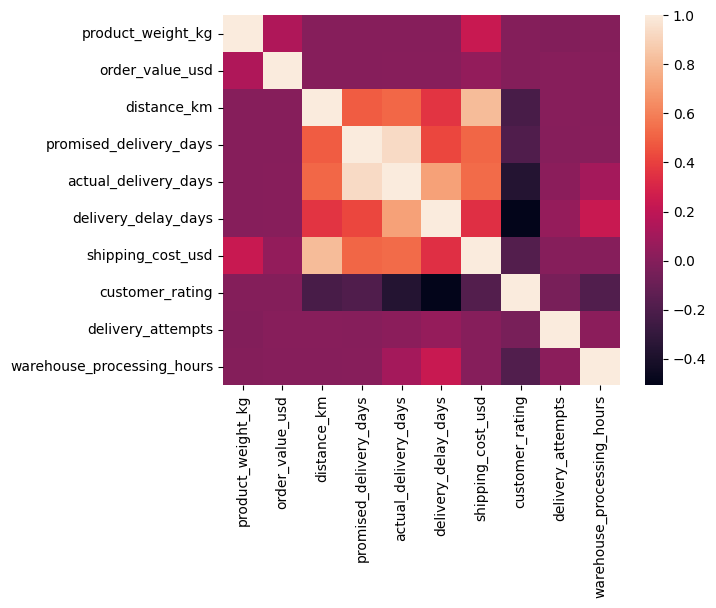

In [89]:
sns.heatmap(corr)

In [90]:
df.duplicated().sum()

np.int64(0)

## Converting order date


In [91]:
df['order_date']=pd.to_datetime(df['order_date'])


In [92]:
df['order_date'].min()
df['order_date'].max()

Timestamp('2026-12-31 00:00:00')

#  Visualization of Delivery Status Distribution

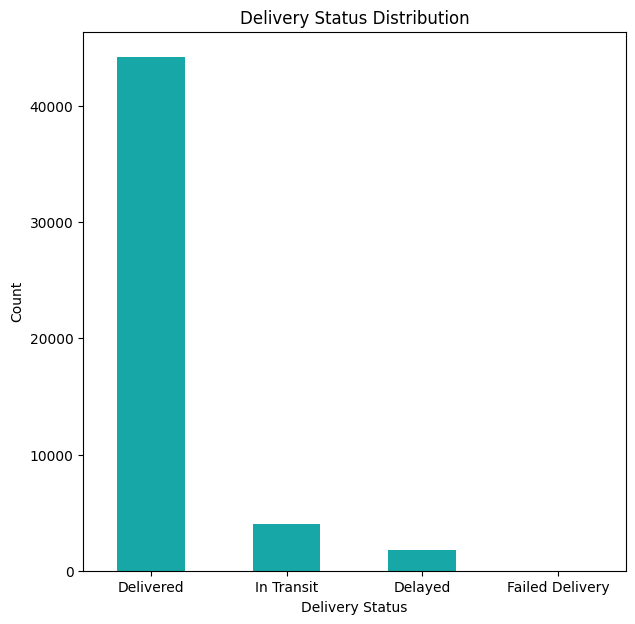

In [93]:
plt.figure(figsize=(7, 7))
sns.countplot(data=df, x='delivery_status',color='c',width=0.5)
plt.title('Delivery Status Distribution')
plt.xlabel('Delivery Status')
plt.ylabel('Count')
plt.show()

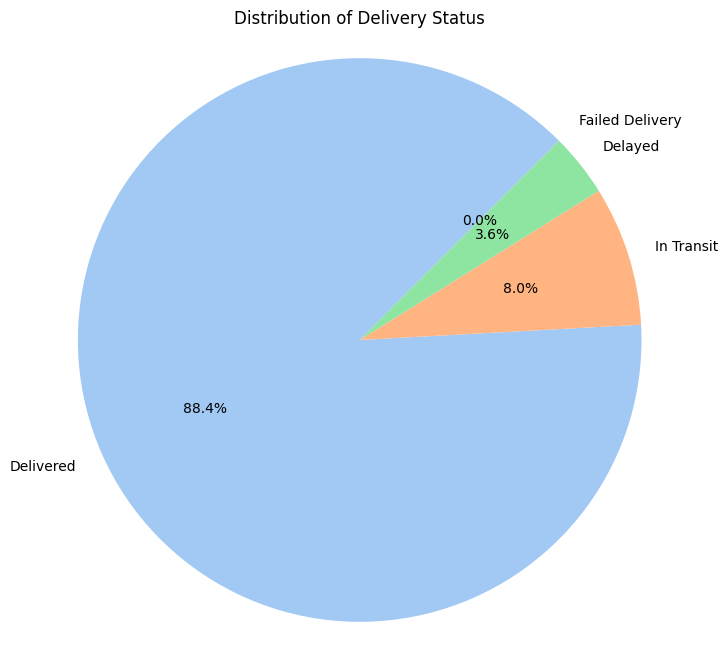

In [94]:


plt.figure(figsize=(8,8 ))
delivery_status_counts = df['delivery_status'].value_counts()
plt.pie(delivery_status_counts, labels=delivery_status_counts.index, autopct='%1.1f%%', startangle=45, colors=sns.color_palette('pastel'))
plt.title('Distribution of Delivery Status')
plt.axis('equal')
plt.show()

In [95]:
df['delivery_status'].value_counts()

,count
delivery_status,
Delivered,44184
In Transit,4007
Delayed,1806
Failed Delivery,3


## Visualization of Distance vs Delivery Delays

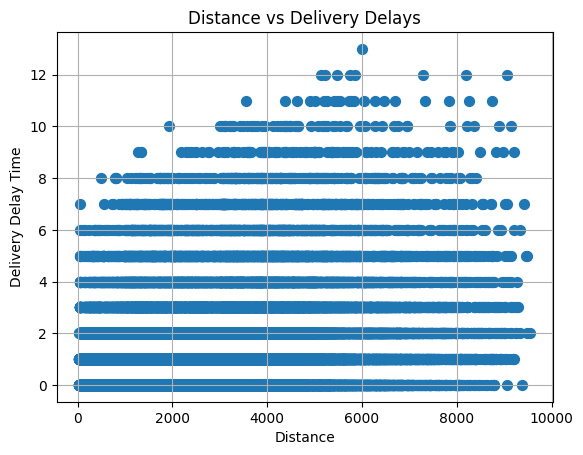

In [96]:
plt.scatter(df['distance_km'], df['delivery_delay_days'],s=50)
plt.xlabel('Distance')
plt.ylabel('Delivery Delay Time')
plt.title('Distance vs Delivery Delays')
plt.grid()
plt.show()

## Commonly used shipping method

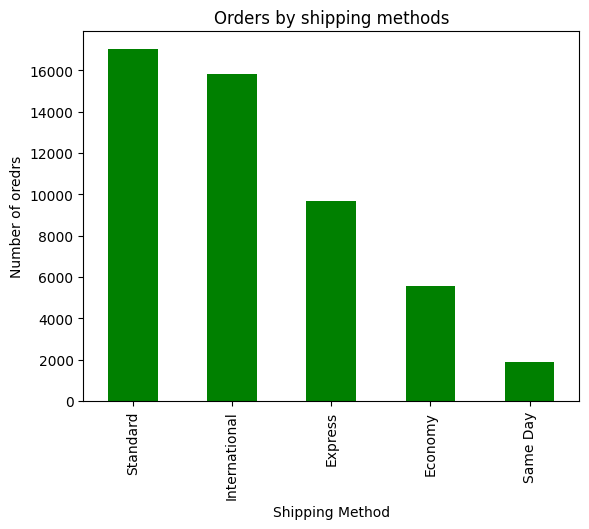

In [97]:
df['shipping_method'].value_counts().plot(kind='bar',color='g')
plt.title('Orders by shipping methods')
plt.xlabel('Shipping Method')
plt.ylabel('Number of oredrs')
plt.show()

## Common payment methods customers used

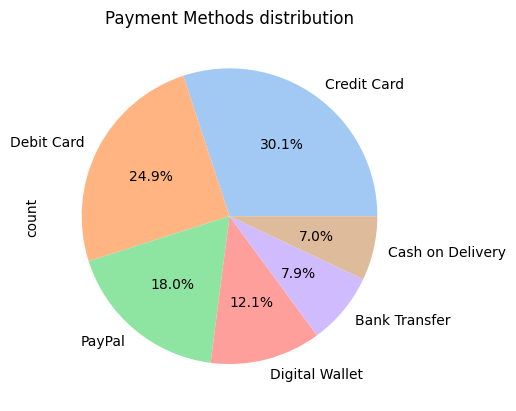

In [98]:

df['payment_method'].value_counts().plot(kind='pie',autopct='%1.1f%%',colors=sns.color_palette('pastel'))
plt.title('Payment Methods distribution')
plt.show()

### Product categories with highest delays

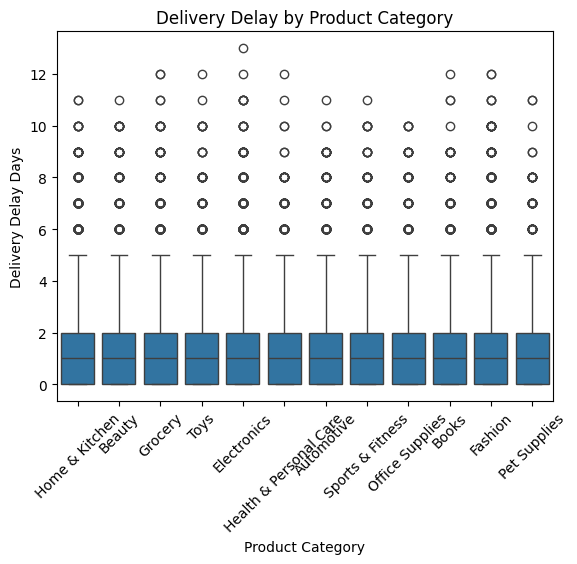

In [99]:
sns.boxplot(data=df,x='product_category',y='delivery_delay_days')
plt.title('Delivery Delay by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Delivery Delay Days')
plt.xticks(rotation=45)
plt.show()